# Phase 2.0 — GENROU on SMIB (4-state two-axis transient model)

**Round-rotor synchronous machine with rotor flux dynamics, no
controllers yet.**

This is the second-simplest dynamic generator model in the smib
library: it replaces GENCLS's "constant E'" approximation with two
flux-state differential equations on the rotor, capturing the
**transient time scale** dynamics that GENCLS was silent on.

**Read first:** [`docs/genrou_physical_foundations.md`](../docs/genrou_physical_foundations.md)
explains every parameter physically — what $X_d$ vs $X'_d$ mean, why
$T'_{d0}$ is the L/R of the field winding, why GENCLS is the
$T'_{d0} \to \infty$ limit of GENROU, and so on.  Two SVG diagrams in
that document show the d-axis Park equivalent circuit and the three
reactance regimes over time.

**Sequence in this notebook:**

1. Imports and operating-point setup (recap of Phase 1)
2. The 4-state model — what's new vs GENCLS
3. Initialisation, step by step
4. Flat-line correctness floor
5. Deep inductive fault — GENROU vs GENCLS overlay on the canonical 5
6. The new physics: $E'_q$ and $E'_d$ drift during a long fault
7. CCT comparison — GENROU's CCT is **shorter** than GENCLS's because
   $E'_q$ sags during the fault, reducing post-fault recovery margin
8. Differences vs full PSSE GENROU (no sub-transient yet)
9. Solver flowchart updated for 4 electrical states
10. What lands in Phase 2.1 (ST1A AVR)

**Pre-requisite:** run `bash setup.sh` once at the smib repo root,
then double-click `start_notebook.command` to launch.


## 1. Imports

In [1]:
# Bootstrap so the smib package is importable from notebooks/.
import sys, pathlib
_here = pathlib.Path.cwd()
_root = _here.parent if _here.name == 'notebooks' else _here
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import math
import numpy as np
import plotly.graph_objects as go

from smib.models import GENCLS, GENROU
from smib.network import Network
from smib.powerflow import two_bus_pf
from smib.scenarios import three_phase_fault_schedule
from smib.simulator import run_smib_gencls, run_smib_genrou
from smib.plotting import plot_traces, shade_event_window, plot_sld, CANONICAL

## 2. What's new in GENROU vs GENCLS

GENCLS held the internal EMF $|E'|$ constant for all time
(equivalently: assumed the rotor field flux can't change at all).
That worked for the first ~1 second after a disturbance because the
field winding's $L/R$ time constant $T'_{d0}$ is around 8 seconds —
long compared to a typical fault.

GENROU drops that approximation and treats the rotor flux as a real
differential-equation state.  Specifically, **two extra electrical
states**:

| State | What it tracks |
|---|---|
| $E'_q$ | Field-winding flux linkage, scaled to per-unit stator voltage. Decays toward $E_{fd}$ on time constant $T'_{d0} \approx 8$ s. |
| $E'_d$ | Slow q-axis damper flux, scaled. Decays toward zero on time constant $T'_{q0} \approx 1$ s for round rotor. |

Plus the same two mechanical states from GENCLS ($\delta$ and slip
$\bar\omega$).  **Total: 4 states.**

The differential equations:

$$ T'_{d0}\,\dfrac{dE'_q}{dt} = E_{fd} - E'_q - (X_d - X'_d)\,I_d - S_e(|E'_q|)\,E'_q $$

$$ T'_{q0}\,\dfrac{dE'_d}{dt} = -E'_d + (X_q - X'_q)\,I_q $$

$$ \dfrac{d\delta}{dt} = \omega_0\,\bar\omega \qquad
   2H\,\dfrac{d\bar\omega}{dt} = P_m - P_e - D\,\bar\omega $$

Output equations (terminal voltage in machine dq):

$$ V_q = -X'_d\,I_d + E'_q \qquad V_d = +X'_q\,I_q + E'_d $$

$P_e = V_d \cdot I_d + V_q \cdot I_q$.

Saturation $S_e(|E'_q|) = B(|E'_q| - A)^2$ for $|E'_q| > A$, fit from
$S(1.0)$ and $S(1.2)$.  At our operating point $|E'_q| \approx 0.92$
which is below the saturation knee at $A \approx 0.79$ — *barely*
saturated, so $S_e$ is small but non-zero in normal operation.

**One simplification vs full PSSE GENROU**: we don't include the
sub-transient detail (the two extra states $\psi''_d$ and $\psi''_q$
and the sub-transient reactances $X''_d$ and $X''_q$).  See §8 for
what this costs.

## 3. Operating point — same as Phase 1

We reuse the Phase 1 SMIB exactly so GENROU vs GENCLS overlays come
out clean.

In [2]:
P, Q = 0.8, 0.2
R_line, X_line = 0.0, 0.5
V_inf = 1.0 + 0j

V1, iters = two_bus_pf(P, Q, abs(V_inf), 0.0, R_line, X_line, bus_type='PQ')
print(f'PF converged in {iters} iters: V1 = {abs(V1):.4f} pu /_ {math.degrees(np.angle(V1)):.3f} deg')

PF converged in 5 iters: V1 = 1.0178 pu /_ 23.142 deg


In [3]:
# SLD (same as Phase 1 — PF doesn't change between models).
fig = plot_sld(V_gen=V1, S_gen=complex(P, Q), V_inf=V_inf,
               R_line=R_line, X_line=X_line, gen_label='GENROU',
               title='SMIB single-line diagram (Phase 2.0, post-LF)')
fig.show()

## 4. Initialisation — five-step protocol

Six steady-state quantities must be computed at $t = 0$: $\delta$,
$\bar\omega$, $E'_q$, $E'_d$, $E_{fd}$, $P_m$.  The protocol:

1. Terminal current: $I = \overline{S/V}$.
2. Rotor angle: $\delta = \arg(V + j X_q I)$ — phasor behind $X_q$,
   the canonical Kundur classical formula for round rotor.
3. Project $V$ and $I$ into machine dq using the PSSE/Kundur convention:
   $V_q = \mathrm{Re}(V e^{-j\delta})$, $V_d = -\mathrm{Im}(V e^{-j\delta})$.
4. Steady-state output equations give $E'_q$ and $E'_d$:
   $$ E'_q = V_q + X'_d\,I_d \qquad E'_d = V_d - X'_q\,I_q $$
   The differential equation steady state must agree:
   $E'_d|_{\text{diff,ss}} = (X_q - X'_q)\,I_q$.  If not, sign
   conventions are off.
5. Field voltage and mechanical power:
   $$ E_{fd} = E'_q + (X_d - X'_d)\,I_d + S_e\,E'_q \qquad P_m = V_d I_d + V_q I_q $$

In [4]:
# Step 1 — terminal current.
S = complex(P, Q)
I_term = np.conj(S / V1)
print(f'I_term = {abs(I_term):.4f} pu  /_  {math.degrees(np.angle(I_term)):.3f} deg')

# Step 2 — rotor angle (phasor behind X_q).
Xq = 1.76
E_a = V1 + 1j * Xq * I_term
delta_0 = float(np.angle(E_a))
print(f'delta_0 = {math.degrees(delta_0):.3f} deg   (vs GENCLS angle = 35.495 deg — much larger because Xq >> X\'d)')
print(f'|E_a (behind Xq)| = {abs(E_a):.4f} pu')

# Step 3 — project to machine dq.
Vq = float((V1 * np.exp(-1j * delta_0)).real)
Vd = -float((V1 * np.exp(-1j * delta_0)).imag)
Iq = float((I_term * np.exp(-1j * delta_0)).real)
Id = -float((I_term * np.exp(-1j * delta_0)).imag)
print(f'Vq = {Vq:+.4f}, Vd = {Vd:+.4f}')
print(f'Iq = {Iq:+.4f}, Id = {Id:+.4f}')

# Step 4 — Eqp and Edp from output equations.
Xd, Xdp, Xqp = 1.81, 0.30, 0.65
Eqp_manual = Vq + Xdp * Id
Edp_manual = Vd - Xqp * Iq
print(f"Eqp (manual) = Vq + X'd·Id = {Eqp_manual:.4f} pu")
print(f"Edp (manual) = Vd - X'q·Iq = {Edp_manual:.4f} pu")

# Cross-check: differential equation steady state.
Edp_diff_ss = (Xq - Xqp) * Iq
print(f"Edp (diff eq ss) = (Xq - X'q)·Iq = {Edp_diff_ss:.4f} pu")
print(f"Mismatch: {abs(Edp_manual - Edp_diff_ss):.3e}  (must be near 0 for sign-consistent equations)")

I_term = 0.8102 pu  /_  9.106 deg
delta_0 = 68.554 deg   (vs GENCLS angle = 35.495 deg — much larger because Xq >> X'd)
|E_a (behind Xq)| = 1.9425 pu
Vq = +0.7145, Vd = +0.7248
Iq = +0.4118, Id = +0.6977
Eqp (manual) = Vq + X'd·Id = 0.9238 pu
Edp (manual) = Vd - X'q·Iq = 0.4571 pu
Edp (diff eq ss) = (Xq - X'q)·Iq = 0.4571 pu
Mismatch: 2.220e-16  (must be near 0 for sign-consistent equations)


In [5]:
# Step 5 — encapsulated init via GENROU class, cross-check.
g = GENROU()
g.initialise(V1, S)

print('--- Side-by-side: manual vs encapsulated initialisation ---')
print(f'delta_0 :  manual {math.degrees(delta_0):.4f} deg  vs  GENROU {math.degrees(g.state["delta"]):.4f} deg')
print(f'Eqp     :  manual {Eqp_manual:.5f} pu      vs  GENROU {g.state["Eqp"]:.5f} pu')
print(f'Edp     :  manual {Edp_manual:.5f} pu      vs  GENROU {g.state["Edp"]:.5f} pu')
print(f'Efd     :  GENROU {g.params["Efd"]:.5f} pu      (≈ |E_a behind Xd|, accounts for saturation)')
print(f'Pm      :  GENROU {g.params["Pm"]:.5f} pu      (must equal P = {P})')

--- Side-by-side: manual vs encapsulated initialisation ---
delta_0 :  manual 68.5540 deg  vs  GENROU 68.5540 deg
Eqp     :  manual 0.92381 pu      vs  GENROU 0.92381 pu
Edp     :  manual 0.45714 pu      vs  GENROU 0.45714 pu
Efd     :  GENROU 2.02563 pu      (≈ |E_a behind Xd|, accounts for saturation)
Pm      :  GENROU 0.80000 pu      (must equal P = 0.8)


## 5. Flat-line — the correctness floor

If all six initial quantities are consistent, every derivative is
zero at $t = 0$ and stays at zero forever in the absence of
disturbance.  Any drift here means the dq sign convention is broken
or the steady-state equations are off.

In [6]:
g = GENROU()
n = Network(R=R_line, X=X_line, V_slack_mag=abs(V_inf))
res = run_smib_genrou(g, n, t_end=10.0, h=2e-3, init_V=V1, init_S=S)

drifts = {
    'delta [deg]': math.degrees(abs(res.traces['delta'] - res.traces['delta'][0]).max()),
    'omega [pu]':  abs(res.traces['omega']).max(),
    'Eqp [pu]':    abs(res.traces['Eqp'] - res.traces['Eqp'][0]).max(),
    'Edp [pu]':    abs(res.traces['Edp'] - res.traces['Edp'][0]).max(),
}
print('10-second flat-line drift:')
for k, v in drifts.items():
    print(f'  {k:>14s} : {v:.3e}')
print('PASS' if max(drifts.values()) < 1e-5 else 'FAIL')

10-second flat-line drift:
     delta [deg] : 3.817e-14
      omega [pu] : 1.767e-16
        Eqp [pu] : 0.000e+00
        Edp [pu] : 0.000e+00
PASS


## 6. Deep inductive fault — GENROU vs GENCLS, side by side

Apply the same fault as Phase 1 ($Z_f = j\,0.10$ pu, 100 ms cleared)
to both models at the same operating point.  Plot the canonical 5
plus the two new GENROU rotor-flux states.

**Expected differences:**

- Pre-fault and steady state: identical (both models initialise to
  the same operating point).
- During the fault: most traces match closely; the new $E'_q$ and
  $E'_d$ traces show GENROU's rotor flux dynamics — flat in GENCLS
  (constant flux assumption), changing in GENROU (transient
  time scale).
- Post-fault: minor differences as the rotor angle and flux
  oscillations interact.

In [7]:
# Run GENCLS.
g_cls = GENCLS(H=4.0, D=0.0, Xdp=0.30, f0=50.0)
n_cls = Network(R=R_line, X=X_line, V_slack_mag=abs(V_inf))
fault_cls = three_phase_fault_schedule(t_start=1.0, t_clear=1.10, Z_fault=0+0.10j)
res_cls = run_smib_gencls(g_cls, n_cls, t_end=5.0, h=2e-3,
                          scenarios=[fault_cls], init_V=V1, init_S=S)

# Run GENROU.
g_rou = GENROU()
n_rou = Network(R=R_line, X=X_line, V_slack_mag=abs(V_inf))
fault_rou = three_phase_fault_schedule(t_start=1.0, t_clear=1.10, Z_fault=0+0.10j)
res_rou = run_smib_genrou(g_rou, n_rou, t_end=5.0, h=2e-3,
                          scenarios=[fault_rou], init_V=V1, init_S=S)

# Build overlay plot — canonical 5 + new states.
from plotly.subplots import make_subplots
labels = ['P', 'Q', '|V|', 'Id', 'Iq']
extras = [('delta [deg]', lambda r: np.degrees(r.traces['delta'])),
          ('omega [pu]', lambda r: r.traces['omega'])]
genrou_only = [('Eqp [pu]', lambda r: r.traces['Eqp']),
               ('Edp [pu]', lambda r: r.traces['Edp'])]

n_rows = len(labels) + len(extras) + len(genrou_only)
fig = make_subplots(rows=n_rows, cols=1, shared_xaxes=True, vertical_spacing=0.018)
row = 1
for lbl in labels:
    fig.add_trace(go.Scatter(x=res_cls.t, y=res_cls.traces[lbl],
                             name='GENCLS', line=dict(color='#1565C0', width=1.5),
                             showlegend=(row==1)), row=row, col=1)
    fig.add_trace(go.Scatter(x=res_rou.t, y=res_rou.traces[lbl],
                             name='GENROU', line=dict(color='#E65100', width=1.5, dash='dash'),
                             showlegend=(row==1)), row=row, col=1)
    fig.update_yaxes(title_text=lbl, row=row, col=1)
    row += 1

for lbl, getter in extras:
    fig.add_trace(go.Scatter(x=res_cls.t, y=getter(res_cls),
                             name='GENCLS', line=dict(color='#1565C0', width=1.5),
                             showlegend=False), row=row, col=1)
    fig.add_trace(go.Scatter(x=res_rou.t, y=getter(res_rou),
                             name='GENROU', line=dict(color='#E65100', width=1.5, dash='dash'),
                             showlegend=False), row=row, col=1)
    fig.update_yaxes(title_text=lbl, row=row, col=1)
    row += 1

for lbl, getter in genrou_only:
    fig.add_trace(go.Scatter(x=res_rou.t, y=getter(res_rou),
                             name='GENROU', line=dict(color='#E65100', width=1.5, dash='dash'),
                             showlegend=False), row=row, col=1)
    fig.update_yaxes(title_text=lbl, row=row, col=1)
    row += 1

fig.update_xaxes(title_text='time [s]', row=n_rows, col=1)
fig.update_layout(title='GENCLS vs GENROU — deep inductive fault Z_f = j*0.10 pu',
                  height=140 * n_rows, template='plotly_white',
                  margin=dict(l=60, r=20, t=50, b=40))
fig.add_vline(x=1.0, line_dash='dot', line_color='gray', annotation_text='fault on')
fig.add_vline(x=1.10, line_dash='dot', line_color='gray', annotation_text='fault clear')
fig.show()

# Print diagnostic comparison.
mid = res_rou.t.searchsorted(1.05)
print(f'\nMid-fault snapshot (t=1.05s):')
print(f'                GENCLS    GENROU    Δ')
print(f'  |V|         : {res_cls.traces["|V|"][mid]:+.4f}  {res_rou.traces["|V|"][mid]:+.4f}  {res_rou.traces["|V|"][mid]-res_cls.traces["|V|"][mid]:+.4f}')
print(f'  P           : {res_cls.traces["P"][mid]:+.4f}  {res_rou.traces["P"][mid]:+.4f}  {res_rou.traces["P"][mid]-res_cls.traces["P"][mid]:+.4f}')
print(f'  Q           : {res_cls.traces["Q"][mid]:+.4f}  {res_rou.traces["Q"][mid]:+.4f}  {res_rou.traces["Q"][mid]-res_cls.traces["Q"][mid]:+.4f}')
print(f'  delta [deg] : {math.degrees(res_cls.traces["delta"][mid]):+.2f}    {math.degrees(res_rou.traces["delta"][mid]):+.2f}    {math.degrees(res_rou.traces["delta"][mid]-res_cls.traces["delta"][mid]):+.2f}')
print(f'  Eqp (GENROU only) : pre={res_rou.traces["Eqp"][0]:.4f}, mid-fault={res_rou.traces["Eqp"][mid]:.4f}, drift={res_rou.traces["Eqp"][mid]-res_rou.traces["Eqp"][0]:+.4f}')


Mid-fault snapshot (t=1.05s):
                GENCLS    GENROU    Δ
  |V|         : +0.3526  +0.3052  -0.0474
  P           : +0.2889  +0.3281  +0.0392
  Q           : +0.8484  +0.6030  -0.2455
  delta [deg] : +37.08    +70.00    +32.92
  Eqp (GENROU only) : pre=0.9238, mid-fault=0.9088, drift=-0.0150


## 7. The new physics — $E'_q$ drift during the fault

GENCLS holds $|E'|$ constant by assumption.  GENROU lets it evolve
according to:

$$ T'_{d0}\,\dfrac{dE'_q}{dt} = E_{fd} - E'_q - (X_d - X'_d)\,I_d - S_e\,E'_q $$

During the fault, $|V|$ collapses → terminal current $I_d$ surges
(demagnetising direction) → the $-(X_d - X'_d)\,I_d$ term pulls
$E'_q$ down.  $E_{fd}$ is fixed at its initial value (no AVR yet),
so $E'_q$ has nothing pushing back, and it sags.

In the trace above you can see $E'_q$ drift downward from ~0.924 to
~0.91 over the 100 ms fault — modest because the fault is short
relative to $T'_{d0} = 8$ s, but visible.  Over a longer fault the
drift would be larger, and post-fault recovery would be weaker
because the rotor effectively has less "stored magnetic energy" to
push back.

**This is exactly why an AVR matters.**  An AVR senses $|V|$ falling
and ramps $E_{fd}$ up toward its ceiling, actively keeping $E'_q$
from sagging.  Phase 2.1 adds ST1A and we re-run this same fault —
$E'_q$ should stay closer to its pre-fault value, and the CCT should
extend.

## 8. CCT comparison — GENROU is *more conservative* than GENCLS

Bisect on fault duration for both models, using **the same deep
inductive fault as §6** ($Z_f = j\,0.10$ pu).  Two reasons we compare
on this fault rather than the textbook bolted-fault limit:

1. **Apples-to-apples with §6** — the headline visualisation uses
   this fault, so the CCT we report should be from the same
   scenario.
2. **The bolted-fault EAC formula doesn't apply to either model**
   here — for shunt-at-gen-bus faults $P_{e,\text{flt}}(\delta)$ is
   not a scaled sine (see §6.1 of the Phase 1 notebook), so the
   simulator is the truth and we don't gain anything from comparing
   to the textbook bolted EAC.

A bolted-fault row is included for reference only.

In [8]:
def is_stable_gencls(t_clear, Z_f):
    g = GENCLS(H=4.0, D=0.0, Xdp=0.30, f0=50.0)
    n = Network(R=R_line, X=X_line, V_slack_mag=abs(V_inf))
    f = three_phase_fault_schedule(1.0, 1.0+t_clear, Z_f)
    r = run_smib_gencls(g, n, t_end=5.0, h=2e-3, scenarios=[f], init_V=V1, init_S=S)
    delta0 = r.traces['delta'][0]
    return abs(r.traces['delta'] - delta0).max() < 2*math.pi

def is_stable_genrou(t_clear, Z_f):
    g = GENROU()
    n = Network(R=R_line, X=X_line, V_slack_mag=abs(V_inf))
    f = three_phase_fault_schedule(1.0, 1.0+t_clear, Z_f)
    r = run_smib_genrou(g, n, t_end=5.0, h=2e-3, scenarios=[f], init_V=V1, init_S=S)
    delta0 = r.traces['delta'][0]
    return abs(r.traces['delta'] - delta0).max() < 2*math.pi

def bisect_cct(is_stable_fn, Z_f, lo=0.05, hi=1.5, n=12):
    for _ in range(n):
        mid = 0.5*(lo+hi)
        if is_stable_fn(mid, Z_f):
            lo = mid
        else:
            hi = mid
    return 0.5*(lo+hi)

print(f'CCT comparison across fault depths:')
print(f'{"Fault":>22}  {"GENCLS":>10}  {"GENROU":>10}  {"Δ":>9}  {"% drop":>8}')
print('-' * 65)
for label, Z_f, hi in [
    ('Bolted   (j*0.001)', 0+0.001j, 0.5),
    ('Deep §6  (j*0.10)',  0+0.10j,  1.5),
    ('Medium   (j*0.20)',  0+0.20j,  2.0),
]:
    cct_cls = bisect_cct(is_stable_gencls, Z_f, lo=0.05, hi=hi, n=10)
    cct_rou = bisect_cct(is_stable_genrou, Z_f, lo=0.05, hi=hi, n=10)
    pct = (cct_rou - cct_cls) / cct_cls * 100
    print(f'{label:>22}  {cct_cls*1000:>7.0f} ms  {cct_rou*1000:>7.0f} ms  {(cct_rou-cct_cls)*1000:>+6.0f} ms  {pct:>+6.1f}%')

print(f'\n→ GENROU is MORE CONSERVATIVE because Eqp sags during the fault.')
print('  The longer the fault, the bigger the sag, the bigger the CCT gap.')
print('  AVR (Phase 2.1) keeps Eqp UP and recovers most of this gap.')

CCT comparison across fault depths:
                 Fault      GENCLS      GENROU          Δ    % drop
-----------------------------------------------------------------


    Bolted   (j*0.001)      205 ms      165 ms     -40 ms   -19.5%


     Deep §6  (j*0.10)      318 ms      262 ms     -57 ms   -17.8%


     Medium   (j*0.20)      472 ms      365 ms    -107 ms   -22.6%

→ GENROU is MORE CONSERVATIVE because Eqp sags during the fault.
  The longer the fault, the bigger the sag, the bigger the CCT gap.
  AVR (Phase 2.1) keeps Eqp UP and recovers most of this gap.


## 9. Differences vs full PSSE GENROU

This 4-state model is **simplified** relative to PSSE's GENROU.  The
key omissions and what they cost:

| Missing | What it adds | Practical effect |
|---|---|---|
| Sub-transient states $\psi''_d$, $\psi''_q$ | Two more flux states for the fast damper windings | First ~50 ms of any fault response: the apparent reactance is $X''_d$ in PSSE (≈ 0.23) vs $X'_d$ here (≈ 0.30). PSSE's initial fault current is ~30 % bigger. Beyond 50 ms they converge. |
| Sub-transient reactances $X''_d$, $X''_q$ | Used in the output equations instead of $X'$ | Same as above. |
| Sub-transient time constants $T''_{d0}$, $T''_{q0}$ | L/R of the fast damper windings (~30 ms d, ~70 ms q) | Determine how fast the sub-transient regime decays. |
| Leakage reactance $X_l$ | Appears in the GENROU compensated-current terms and saturation | Without it we can't form $\gamma_d$, $\gamma_q$ that connect transient and sub-transient. Saturation here acts on $\|E'_q\|$ instead of the full air-gap flux. |
| Faster q-axis damper $T''_{q0}$ | Adds a second q-axis flux state | Same first-50-ms effect as the d-axis. |

**When the simplification matters:**

- **Protection studies** that need accurate first-cycle fault current
  magnitudes — PSSE's $X''_d$ gives a ~30 % bigger initial spike.
- **Sub-synchronous resonance** studies — needs the full sub-transient
  detail.
- **High-fidelity SCR sweeps** for IBR weak-grid stability — the fast
  damper damping interacts with the PLL.

**When the simplification is fine:**

- **First-swing transient stability** (CCT, equal-area, fault
  recovery) — the swing happens over hundreds of ms, dominated by
  $T'_{d0}$ and $T'_{q0}$.
- **AVR/PSS controller pedagogy** (Phase 2.1, 2.2) — controllers
  operate on the swing time scale; sub-transient details don't move
  the needle.
- **Comparing inverter-vs-machine grid behaviour** at the system
  level (Phase 3 onward).

**Phase 2.0b** (potential future increment): add $\psi''_d, \psi''_q$
back in.  We deferred them because they introduce extra sign
conventions and PSSE-vs-Sauer-Pai notation differences that took
time to debug, and the swing-stability pedagogy doesn't need them.

## 10. Under the hood — solver flowchart for GENROU

The integrator structure is identical to Phase 1's, but with **four
electrical states** instead of two and a **2×2 saliency-aware
algebraic network solve** instead of the Norton-folded scalar.

The orange "compute dx/dt" box now evaluates four equations at once
(two electrical, two mechanical), and the blue "solve network" box
solves a 2×2 linear system (in the real and imaginary parts of $V$)
because $X'_d \ne X'_q$ means a single Norton admittance scalar
isn't enough.

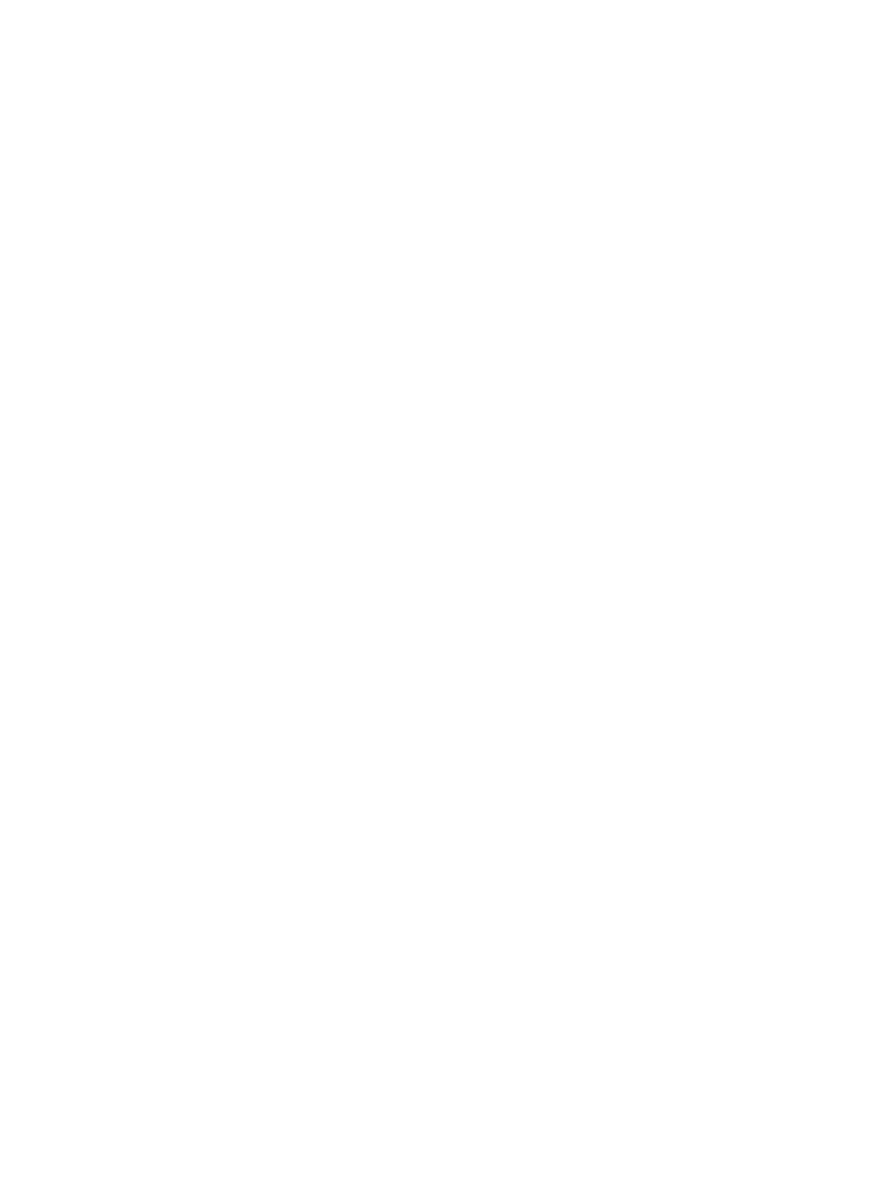

In [9]:
# Reuse the Phase 1 solver flowchart for the conceptual structure;
# the same boxes apply.
from IPython.display import SVG, display
display(SVG(filename='figs/trapezoidal_flow.svg'))

**Phase 2.0 specific notes on the solver flow:**

- The orange "$f_0 = $ derivatives" box now returns a 4-vector
  $(\dot\delta, \dot{\bar\omega}, \dot E'_q, \dot E'_d)$ instead of
  the 2-vector from GENCLS.
- The blue "solve_net" box uses
  ``smib.simulator._solve_network_with_genrou`` which builds a 2×2
  matrix from the model's algebraic output equations and solves
  directly — no fixed-point iteration on the algebraic loop.
- The trapezoidal corrector (red dashed loop in the diagram) still
  needs 2-3 iterations per timestep for GENROU on this scenario,
  same as GENCLS.

## 11. What's coming in Phase 2.1 (ST1A AVR)

The big gap GENROU-bare leaves: **no automatic voltage regulation**.
$E_{fd}$ is fixed at its initial value, so during a fault $E'_q$
sags and we can't push more reactive support into the grid than the
constant-flux limit allows.

Phase 2.1 adds **ST1A** — IEEE 421.5 Type ST1A static exciter:

- Senses terminal voltage $|V|$ via a transducer with time constant
  $T_R$
- Compares to a reference $V_{\text{ref}}$
- Drives error through a PI loop with high gain $K_A \approx 200{-}400$
- Output is $E_{fd}$, clamped between $V_{\text{rmin}}$ and
  $V_{\text{rmax}}$ (the field ceiling, typically 5-7× rated)

Three new states: terminal-voltage transducer, regulator integrator,
and a lead-lag block.

**The headline plot in Phase 2.1** will be the same fault we just
ran, with and without the AVR overlaid.  Expected differences:

- $|V|$ recovers faster post-fault
- $Q$ rises more aggressively during the fault
- $E_{fd}$ ramps from its initial value (~2.0) toward the ceiling
  (~5-7) during the LV window
- $E'_q$ stays much closer to its pre-fault value (instead of sagging
  as in GENROU-bare)
- CCT extends — the AVR's reactive support gives the rotor more
  decelerating area post-fault.

**Phase 2.2** adds PSS1A on top — the small-signal damping injector
that lets the AVR not destabilise the local rotor mode.  Headline
plot: same fault, AVR-only vs AVR+PSS, showing the local-mode
oscillation kill.

**Phase 2.3** completes the classical stack with TGOV1 — droop-based
primary frequency response on a load step.